In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [3]:
#Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [ ]:
#Split the Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
#Normalize the Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
#Model 1 – Neural Network with ReLU
relu_model = Sequential()

relu_model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
relu_model.add(Dense(8, activation='relu'))
relu_model.add(Dense(1, activation='sigmoid'))

relu_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

relu_history = relu_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

c:\Users\Bindu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4231 - loss: 0.6991 - val_accuracy: 0.3846 - val_loss: 0.6724
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5549 - loss: 0.6311 - val_accuracy: 0.7582 - val_loss: 0.6244
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8462 - loss: 0.5779 - val_accuracy: 0.8791 - val_loss: 0.5778
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9368 - loss: 0.5240 - val_accuracy: 0.9121 - val_loss: 0.5190
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9560 - loss: 0.4545 - val_accuracy: 0.9231 - val_loss: 0.4474
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.3811 - val_accuracy: 0.9341 - val_loss: 0.3791
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9615 - loss: 0.3161 - val_accuracy: 0.9451 - val_loss: 0.3228
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9588 - loss: 0.2626 - val_accuracy: 0.9451 - val_loss

In [7]:
#Model 2 – Neural Network with Sigmoid 
sigmoid_model = Sequential()

sigmoid_model.add(Dense(16, activation='sigmoid', input_shape=(X_train.shape[1],)))
sigmoid_model.add(Dense(8, activation='sigmoid'))
sigmoid_model.add(Dense(1, activation='sigmoid'))

sigmoid_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

sigmoid_history = sigmoid_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3736 - loss: 0.7789 - val_accuracy: 0.3626 - val_loss: 0.7584
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3736 - loss: 0.7418 - val_accuracy: 0.3626 - val_loss: 0.7215
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3736 - loss: 0.7074 - val_accuracy: 0.3626 - val_loss: 0.6897
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3929 - loss: 0.6779 - val_accuracy: 0.5385 - val_loss: 0.6609
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7088 - loss: 0.6507 - val_accuracy: 0.8352 - val_loss: 0.6350
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8764 - loss: 0.6267 - val_accuracy: 0.9121 - val_loss: 0.6109
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9038 - loss: 0.6035 - val_accuracy: 0.9341 - val_loss: 0.5893
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9038 - loss: 0.5822 - val_accuracy: 0.9121 - val_los

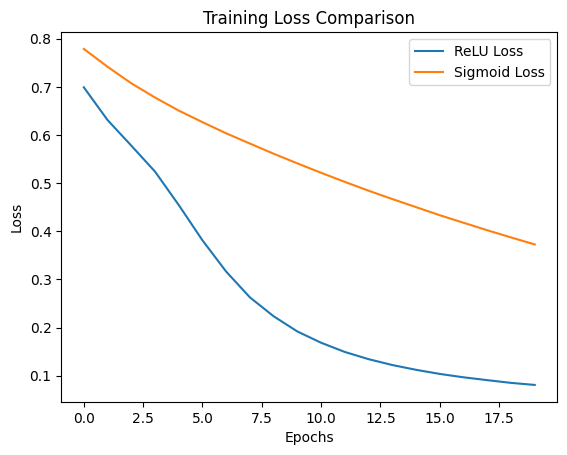

In [8]:
#Compare Training Performance 
plt.plot(relu_history.history['loss'], label='ReLU Loss')
plt.plot(sigmoid_history.history['loss'], label='Sigmoid Loss')

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [9]:
#Evaluate Models
relu_score = relu_model.evaluate(X_test, y_test)
sigmoid_score = sigmoid_model.evaluate(X_test, y_test)

print("ReLU Model Accuracy:", relu_score[1])
print("Sigmoid Model Accuracy:", sigmoid_score[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9737 - loss: 0.0869 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9561 - loss: 0.3562 
ReLU Model Accuracy: 0.9736841917037964
Sigmoid Model Accuracy: 0.9561403393745422
